# Anthropic compute Monte Carlo — cloud-spend version

This is an **alternate** estimate of Anthropic's 2025 compute, built bottom-up
from **cloud compute spend** rather than from a power figure. The companion
notebook `anthropic_compute_monte_carlo.py` anchors on the leaked OpenAI memo's
1.4 GW and gives an **end-of-2025 snapshot**. This one starts from Anthropic's
reported **$6.8B of 2025 cloud spend** and asks how many H100-equivalents that
many dollars buys over the year — so its natural output is a **2025 full-year
average**, not a year-end number. The average is expected to come in *below* the
power snapshot, because the fleet grew through the year (same gap the OpenAI
spend vs. power models showed).

A companion notebook, `anthropic_2024_backcast`, runs this machinery in reverse
to estimate **end-2024** (no power figure exists for that date). That backcast
was originally developed here as §9 and now lives there.

The fleet is split into just **two buckets** (ignoring TPU for now, per the
brief):

- **Nvidia** — Hopper + Blackwell, using the *same* count mix and per-chip specs
  as the OpenAI model, priced at market GPU-hour **rental** rates.
- **Trainium2** — priced off SemiAnalysis's published **total cost of ownership
  of $0.66/chip-hour**. Crucially that is *Amazon's* cost, not the price Amazon
  charges Anthropic, so we put an uncertain **cloud markup** on top of it.

The single biggest lever is how much of the spend goes to Trainium, so — like
the power notebook — we pick a central assumption and then **sweep the Trainium
share** across its full range.

In [1]:
import contextlib
import io
import runpy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squigglepy as sq

N_SAMPLES = 5000
sq.set_seed(42)  # squigglepy has its own RNG; np.random.seed does not affect it

HOURS_PER_YEAR = 8760  # continuous rental implied, matching the OpenAI spend model
BUCKET_COLORS = {'Hopper': '#76b900', 'Blackwell': '#1a73e8', 'Trainium2': '#e8710a'}


def fmt(value):
    """Format an H100e or chip count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

## 1. Borrow the Nvidia specs and the Hopper:Blackwell ratio from the OpenAI model

Exactly as the power-based Anthropic notebook does, we run the OpenAI model once
(quietly) and read out two things so the two notebooks stay consistent:

- **Per-chip H100e** for the Nvidia parts.
- **OpenAI's end-2025 Hopper:Blackwell count ratio.** OpenAI also carries trace
  A100 and some GB300; we drop the A100 and fold GB300 into the Blackwell bucket,
  leaving a clean Hopper-vs-Blackwell split we reuse for Anthropic's Nvidia mix.

In [2]:
def load_openai_namespace():
    """Execute the OpenAI notebook script and hand back its variables, without
    letting its own prints or charts render here."""
    oai_path = ('openai_compute_monte_carlo.py'
                if Path('openai_compute_monte_carlo.py').exists()
                else 'ai-lab-compute/openai_compute_monte_carlo.py')
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None  # swallow the OpenAI figures
    try:
        with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
            warnings.simplefilter('ignore')
            namespace = runpy.run_path(oai_path)
    finally:
        plt.show = original_show
        plt.close('all')
    return namespace


openai = load_openai_namespace()
openai_last_date = openai['last_date']
openai_counts = openai['mc'][openai_last_date]['counts']
oai_h100e = openai['h100e_per_gpu']  # the model calls Blackwell "B200"

# OpenAI's end-2025 Hopper vs Blackwell chip counts (median across its Monte
# Carlo), A100 dropped. This ratio is what we borrow for Anthropic's Nvidia mix.
hopper_units = float(np.median(openai_counts['H100/H200']))
blackwell_units = float(np.median(openai_counts['B200'] + openai_counts['B300']))
hopper_per_blackwell = hopper_units / blackwell_units  # Hopper chips per 1 Blackwell chip

# Per-chip H100e for the two Nvidia buckets and for Trainium2.
HOPPER_H100E = oai_h100e['H100/H200']
BLACKWELL_H100E = oai_h100e['B200']
TRAINIUM2_H100E = 1299 / 1979   # dense 8-bit throughput relative to an H100 (~0.66)

print('Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):')
print(f'   Hopper    : {HOPPER_H100E:.3f} H100e/chip')
print(f'   Blackwell : {BLACKWELL_H100E:.3f} H100e/chip')
print(f'   Hopper:Blackwell count ratio = {hopper_per_blackwell:.2f} : 1')
print(f'   Trainium2 : {TRAINIUM2_H100E:.3f} H100e/chip (independent spec)')

Borrowed from OpenAI end-2025 fleet (A100 dropped, GB300 folded into Blackwell):
   Hopper    : 1.000 H100e/chip
   Blackwell : 2.527 H100e/chip
   Hopper:Blackwell count ratio = 1.22 : 1
   Trainium2 : 0.656 H100e/chip (independent spec)


## 2. Pricing assumptions

**Nvidia (market rental, $/GPU-hour).** Same two scenarios the OpenAI spend
model uses, taken from the research summary:

- low: Hopper \$1.50, Blackwell \$3.00 (SemiAnalysis Aug-2025 3-year-contract survey)
- high: Hopper \$2.00, Blackwell \$4.00 (Silicon Data spot index, early 2026)

We treat each scenario edge as a 90% interval and **correlate** Hopper and
Blackwell (a high-price world lifts both together).

**Trainium2 ($/chip-hour).** SemiAnalysis puts the *total cost of ownership* of a
Trainium2 (Teton2-PD-Ultra-3L) cluster at **\$0.66/chip-hour** — capital plus
operating, from **Amazon's** point of view. (For reference its GB200 NVL72 TCO is
\$2.36, so on a pure-cost basis Trainium2 is far cheaper per chip-hour.) The price
Amazon actually *charges Anthropic* is TCO plus an uncertain **cloud margin**. We
model that as a markup multiplier with a 90% range of **1.0–1.6×** (median ~1.26):
the low end reflects Anthropic's unusually deep Amazon relationship (near-cost
access), the high end a more normal cloud margin.

In [3]:
TRAINIUM2_TCO = 0.66  # $/chip-hour, Amazon's cost (SemiAnalysis)

# Correlated Nvidia rental prices ($/GPU-hour).
hopper_price_dist, blackwell_price_dist = sq.correlate(
    (sq.to(1.50, 2.00), sq.to(3.00, 4.00)), 0.8)
hopper_price = hopper_price_dist @ N_SAMPLES
blackwell_price = blackwell_price_dist @ N_SAMPLES

# Trainium2 price to Anthropic = Amazon's TCO times an uncertain cloud markup.
trainium_markup = sq.to(1.0, 1.6) @ N_SAMPLES
trainium_price = TRAINIUM2_TCO * trainium_markup

print('Prices to Anthropic ($/chip-hour), 5th / median / 95th:')
for name, arr in [('Hopper', hopper_price), ('Blackwell', blackwell_price),
                  ('Trainium2', trainium_price)]:
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {lo:.2f} / {mid:.2f} / {hi:.2f}')

Prices to Anthropic ($/chip-hour), 5th / median / 95th:
   Hopper    : 1.50 / 1.73 / 2.00
   Blackwell : 3.00 / 3.47 / 4.01
   Trainium2 : 0.66 / 0.84 / 1.06


### What a dollar buys in each bucket

The whole model turns on **H100e bought per dollar of annual spend**, which is
just the per-chip H100e divided by a year of rental cost (`price × 8760`). This
is where Trainium's advantage — and its dependence on the markup — shows up. At a
near-cost markup Trainium buys clearly more H100e per dollar than Nvidia; at a
full cloud margin the advantage mostly disappears, consistent with the summary's
"non-Nvidia cheaper per dollar, but well under 2×."

In [4]:
def h100e_per_dollar_year(per_chip_h100e, price_per_hour):
    """H100e bought per $1 of annual spend on a chip rented all year."""
    return per_chip_h100e / (price_per_hour * HOURS_PER_YEAR)


# Express per $1B/year so the numbers are readable.
buckets_per_b = {
    'Hopper': h100e_per_dollar_year(HOPPER_H100E, hopper_price) * 1e9,
    'Blackwell': h100e_per_dollar_year(BLACKWELL_H100E, blackwell_price) * 1e9,
    'Trainium2': h100e_per_dollar_year(TRAINIUM2_H100E, trainium_price) * 1e9,
}
print('\nH100e per $1B of annual spend (5th / median / 95th):')
for name, arr in buckets_per_b.items():
    lo, mid, hi = percentiles(arr)
    print(f'   {name:10s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')


H100e per $1B of annual spend (5th / median / 95th):
   Hopper    : 57k / 66k / 76k
   Blackwell : 72k / 83k / 96k
   Trainium2 : 71k / 89k / 113k


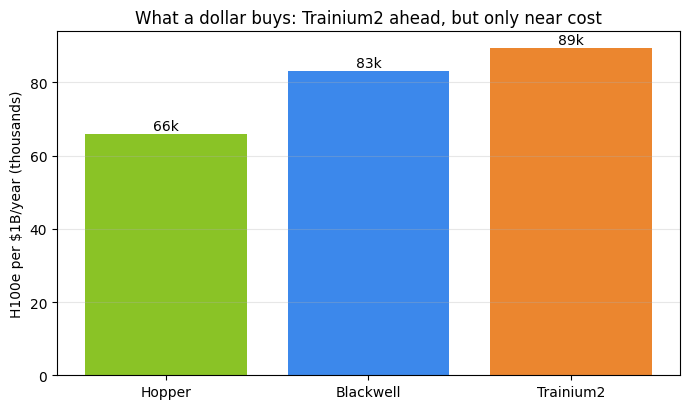

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
medians = {name: np.median(arr) for name, arr in buckets_per_b.items()}
ax.bar(list(medians), [v / 1e3 for v in medians.values()],
       color=[BUCKET_COLORS[n] for n in medians], alpha=0.85)
for col, value in enumerate(medians.values()):
    ax.text(col, value / 1e3 + 1, f'{value / 1e3:,.0f}k', ha='center', fontsize=10)
ax.set_ylabel('H100e per $1B/year (thousands)')
ax.set_title('What a dollar buys: Trainium2 ahead, but only near cost', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 3. Total spend, and growth through the year

Anthropic's reported cloud compute spend is **\$2.5B in 2024** and **\$6.8B in
2025** (media interpretation of leaked documents, via The Information). We center
lognormals on each — 90% ranges \$2.2–2.85B and \$6.0–7.7B — and **correlate them
(0.5)**, since both come from the same reporting and tend to be off in the same
direction.

These are *full-year totals*, so feeding the 2025 total straight into the model
(sections 4–7) gives a **full-year average**. But spend ramped hard through the
year, so the **year-end run-rate** is well above the average. We recover it with
**exponential interpolation**: if the annualized run-rate grows at a constant
continuous rate, the ratio of consecutive full-year totals *is* that year's
growth factor (e raised to the growth rate). From the growth rate we back out the
instantaneous run-rate and read off its value at the end of 2025 — the dollar
figure we plug in for an end-of-year snapshot in section 8.

**The catch:** two annual totals pin down only the *average* growth across the
gap. The instantaneous year-end rate depends on *how* growth was distributed
within the year — front-loaded spend leaves the year-end rate barely above the
average; back-loaded spend leaves it far above. Smooth exponential is just one
path through the two endpoints. So we don't treat the year-end rate as a fixed
multiple of the total: we add a **growth-shape** factor that scales the
instantaneous growth rate (while keeping the 2025 integral equal to the reported
total), centered on the exponential baseline. Below 1 is front-loaded, above 1
back-loaded; the late-2025 ramp narrative argues if anything for the upper half.

In [6]:
# Correlated 2024 and 2025 full-year totals.
spend_2024_dist, spend_2025_dist = sq.correlate((sq.to(2.2, 2.85), sq.to(6.0, 7.7)), 0.5)
spend_2024_total = (spend_2024_dist @ N_SAMPLES) * 1e9
spend_2025_total = (spend_2025_dist @ N_SAMPLES) * 1e9
spend = spend_2025_total  # the full-year average sections (4-7) use the 2025 total

# Average continuous growth implied by the two totals: their ratio = e**g.
avg_growth_rate = np.log(spend_2025_total / spend_2024_total)

# Growth-shape factor: the within-year instantaneous growth rate need not equal the
# two-year average. This is the uncertain annual->instantaneous interpolation step.
# 90% range 0.6-1.6, median ~1 (the exponential baseline).
growth_shape = sq.to(0.6, 1.6) @ N_SAMPLES
inst_growth_rate = avg_growth_rate * growth_shape


def year_end_runrate(total, inst_rate):
    """Year-end annualized run-rate for a year whose spend integrates to `total`
    under an exponential run-rate growing at `inst_rate`. With t=0 at the year's
    start, total = integral over [0,1]; this returns the rate at t=1. As the rate
    -> 0 it tends to `total` (a flat year)."""
    return total * inst_rate / (1 - np.exp(-inst_rate))


spend_2025_end = year_end_runrate(spend_2025_total, inst_growth_rate)

lo, mid, hi = percentiles(spend_2025_total)
print(f'2025 full-year total ($B):       {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}  (5th / median / 95th)')
lo, mid, hi = percentiles(np.exp(avg_growth_rate))
print(f'2024->2025 avg growth factor:    {lo:.2f} / {mid:.2f} / {hi:.2f}')
lo, mid, hi = percentiles(spend_2025_end)
print(f'End-2025 annualized run-rate:    {lo / 1e9:.2f} / {mid / 1e9:.2f} / {hi / 1e9:.2f}')
print(f'   year-end / full-year average: {np.median(spend_2025_end) / np.median(spend_2025_total):.2f}x (median)')

# How much of the run-rate spread is the growth shape vs the totals?
end_shape_only = year_end_runrate(np.median(spend_2025_total),
                                  np.median(avg_growth_rate) * growth_shape)
lo, _, hi = percentiles(end_shape_only)
print(f'   run-rate 90% width from growth shape alone: ${lo / 1e9:.1f}-{hi / 1e9:.1f}B')

2025 full-year total ($B):       5.98 / 6.79 / 7.70  (5th / median / 95th)
2024->2025 avg growth factor:    2.39 / 2.71 / 3.08
End-2025 annualized run-rate:    8.50 / 10.68 / 14.26
   year-end / full-year average: 1.57x (median)
   run-rate 90% width from growth shape alone: $9.0-13.5B


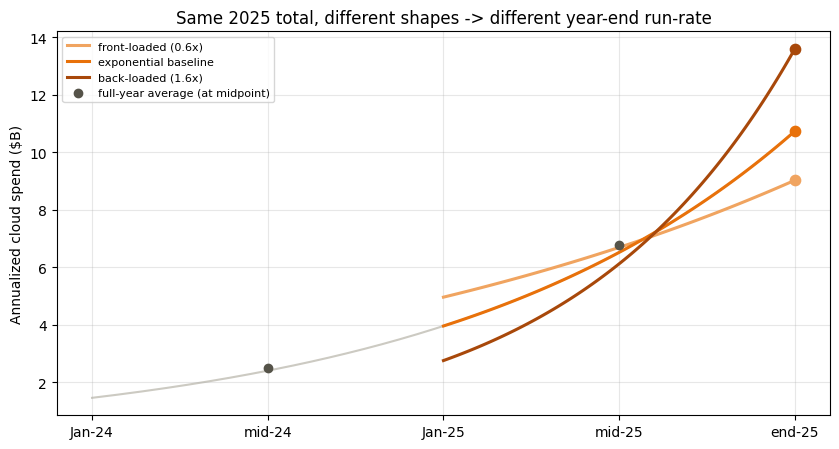

In [7]:
# Illustrative 2025 run-rate paths that all integrate to the same 2025 total but
# differ in shape: front-loaded, exponential baseline, back-loaded. They share the
# full-year average yet diverge sharply at year-end — the uncertainty we just added.
g_med = float(np.log(np.median(spend_2025_total) / np.median(spend_2024_total)))
total24_med, total25_med = float(np.median(spend_2024_total)), float(np.median(spend_2025_total))

fig, ax = plt.subplots(figsize=(8.5, 4.6))

# 2024 segment plus the baseline run-rate across both years, for context.
anchor24 = total24_med * g_med / (np.exp(g_med) - 1)
t_full = np.linspace(0, 2, 200)
ax.plot(t_full, anchor24 * np.exp(g_med * t_full) / 1e9, color='#cccac2', lw=1.5, zorder=1)

# Three 2025 shapes (t in [1,2]); each anchored so its 2025 integral = the total.
u = np.linspace(0, 1, 100)
shapes = [(0.6, '#f0a460', 'front-loaded (0.6x)'),
          (1.0, '#e8710a', 'exponential baseline'),
          (1.6, '#a8480a', 'back-loaded (1.6x)')]
for factor, color, label in shapes:
    g_inst = g_med * factor
    r0 = total25_med * g_inst / (np.exp(g_inst) - 1)
    ax.plot(1 + u, r0 * np.exp(g_inst * u) / 1e9, color=color, lw=2.2, label=label)
    ax.scatter([2.0], [year_end_runrate(total25_med, g_inst) / 1e9], color=color, s=55, zorder=5)

ax.scatter([0.5, 1.5], [total24_med / 1e9, total25_med / 1e9], color='#555349', zorder=6,
           label='full-year average (at midpoint)')
ax.set_xticks([0, 0.5, 1, 1.5, 2])
ax.set_xticklabels(['Jan-24', 'mid-24', 'Jan-25', 'mid-25', 'end-25'])
ax.set_ylabel('Annualized cloud spend ($B)')
ax.set_title('Same 2025 total, different shapes -> different year-end run-rate', fontsize=12)
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. The model

Split the spend into a Trainium2 slice and an Nvidia slice by the **Trainium
share of spend**. Within the Nvidia slice, split between Hopper and Blackwell so
the resulting *chip counts* keep OpenAI's borrowed Hopper:Blackwell ratio — given
that ratio and the two prices, the dollar split is pinned. Each slice then
converts dollars to an annual-average chip count (`dollars ÷ price ÷ 8760`) and
on to H100e.

In [8]:
# With a Hopper:Blackwell count ratio of r:1 and per-hour prices, the share of
# Nvidia dollars going to Hopper is fixed (r Hoppers cost r*price_H, one Blackwell
# costs price_B). This varies per sample because prices do.
hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
    hopper_per_blackwell * hopper_price + blackwell_price)


def anthropic_spend_h100e(total_spend, trainium_spend_share):
    """Annual-average H100e by bucket for the given spend (array) and Trainium2
    share of spend (scalar). Returns per-bucket H100e arrays plus totals."""
    trainium_spend = total_spend * trainium_spend_share
    nvidia_spend = total_spend * (1 - trainium_spend_share)

    # Trainium2 slice.
    trainium_chips = trainium_spend / trainium_price / HOURS_PER_YEAR
    trainium_h100e = trainium_chips * TRAINIUM2_H100E

    # Nvidia slice, split into Hopper and Blackwell.
    hopper_chips = nvidia_spend * hopper_spend_share / hopper_price / HOURS_PER_YEAR
    blackwell_chips = nvidia_spend * (1 - hopper_spend_share) / blackwell_price / HOURS_PER_YEAR
    hopper_h100e = hopper_chips * HOPPER_H100E
    blackwell_h100e = blackwell_chips * BLACKWELL_H100E

    chips = {'Hopper': hopper_chips, 'Blackwell': blackwell_chips, 'Trainium2': trainium_chips}
    h100e = {'Hopper': hopper_h100e, 'Blackwell': blackwell_h100e, 'Trainium2': trainium_h100e}
    return {
        'chips': chips,
        'h100e': h100e,
        'total_chips': sum(chips.values()),
        'total_h100e': sum(h100e.values()),
    }

## 5. Central estimate and the Trainium-share sweep

**Central assumption: Trainium2 takes ~55% of the spend.** Trainium is the
largest single piece of Anthropic's fleet (Project Rainier plus the Mississippi
campus), but it is cheaper per chip-hour, so its *dollar* share sits a bit below
its *compute* share. We report the full distribution at 55% and then sweep the
share from 0 to 90%.

In [9]:
CENTRAL_TRAINIUM_SHARE = 0.55
central = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)

lo, mid, hi = percentiles(central['total_h100e'])
print(f'Central estimate at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share '
      f'(2025 full-year average H100e):')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}\n')
print('   Median H100e by bucket:')
for name in ('Hopper', 'Blackwell', 'Trainium2'):
    print(f'      {name:10s}: {fmt(np.median(central["h100e"][name]))}')

Central estimate at 55% Trainium2 spend share (2025 full-year average H100e):
   5th / median / 95th = 467k / 570k / 695k

   Median H100e by bucket:
      Hopper    : 76k
      Blackwell : 158k
      Trainium2 : 334k


In [10]:
sweep_shares = np.round(np.arange(0.0, 0.901, 0.05), 2)
table_shares = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
sweep = {share: anthropic_spend_h100e(spend, share) for share in sweep_shares}

print(f'{"Trainium2 spend share":>22}   {"H100e (5th / median / 95th)":>30}')
print('-' * 58)
for share in table_shares:
    lo, mid, hi = percentiles(sweep[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

 Trainium2 spend share      H100e (5th / median / 95th)
----------------------------------------------------------
                   0%        431k /     521k /     626k
                  10%        442k /     529k /     631k
                  20%        451k /     539k /     641k
                  30%        459k /     548k /     654k
                  40%        463k /     557k /     669k
                  50%        468k /     566k /     686k
                  60%        468k /     574k /     705k
                  70%        468k /     582k /     727k
                  80%        468k /     591k /     748k
                  90%        468k /     599k /     772k


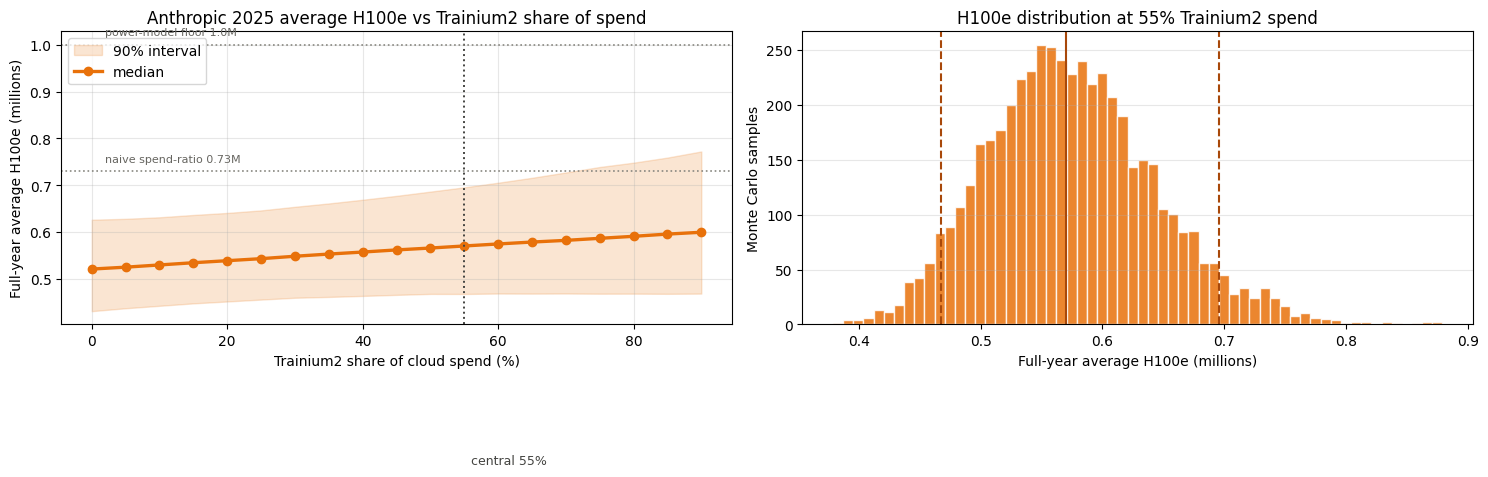

In [11]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: H100e across the Trainium2 spend-share sweep, with the 90% band.
median_curve = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
low_curve = np.array([percentiles(sweep[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
high_curve = np.array([percentiles(sweep[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, low_curve, high_curve, color='#e8710a', alpha=0.18,
                      label='90% interval')
ax_curve.plot(sweep_shares * 100, median_curve, color='#e8710a', lw=2.4, marker='o', label='median')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.text(CENTRAL_TRAINIUM_SHARE * 100 + 1, median_curve[0] * 0.2,
              'central 55%', fontsize=9, color='#444441')

# Outside anchors from the research summary, for orientation.
for value, text in [(0.73, 'naive spend-ratio 0.73M'), (1.0, 'power-model floor 1.0M')]:
    ax_curve.axhline(value, color='#888780', ls=':', lw=1.2)
    ax_curve.text(2, value + 0.02, text, fontsize=8, color='#666560')

ax_curve.set_title('Anthropic 2025 average H100e vs Trainium2 share of spend', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('Full-year average H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: the H100e distribution at the central share.
ax_hist.hist(central['total_h100e'] / 1e6, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#a8480a', ls=style, lw=1.5)
ax_hist.set_title(f'H100e distribution at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend', fontsize=12)
ax_hist.set_xlabel('Full-year average H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Cross-check: implied Trainium2 chip count

Each spend share implies an annual-average Trainium2 chip count. The bottom-up
evidence — Project Rainier (~700k Trainium2 by end-2025) plus the Mississippi
campus — points to several hundred thousand Trainium2 chips, though those are
*year-end* figures while this model is a *full-year average*, so the average
should sit somewhat lower.

In [12]:
print(f'{"Trainium2 spend share":>22} {"Total H100e (median)":>20} {"Trainium2 chips (median)":>26}')
print('-' * 72)
for share in table_shares:
    total_med = np.median(sweep[share]['total_h100e'])
    trainium_chips_med = np.median(sweep[share]['chips']['Trainium2'])
    print(f'{share * 100:>20.0f}%   {fmt(total_med):>17}   {fmt(trainium_chips_med):>23}')

 Trainium2 spend share Total H100e (median)   Trainium2 chips (median)
------------------------------------------------------------------------
                   0%                521k                        0k
                  10%                529k                       93k
                  20%                539k                      185k
                  30%                548k                      278k
                  40%                557k                      370k
                  50%                566k                      463k
                  60%                574k                      556k
                  70%                582k                      648k
                  80%                591k                      741k
                  90%                599k                      833k


## 7. What drives the uncertainty

At the central share, turn each random input on alone (others held at their
median) to see which spreads the full-year H100e the most.

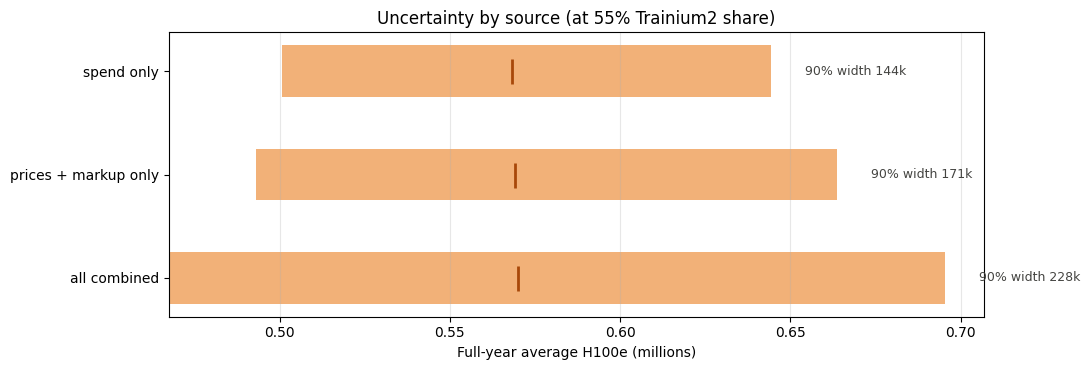

Full-year average H100e by source (5th / median / 95th):
   spend only              : 501k / 568k / 644k
   prices + markup only    : 493k / 569k / 664k
   all combined            : 467k / 570k / 695k


In [13]:
median_spend = float(np.median(spend))
spend_only = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)


def with_fixed_prices():
    """H100e at the central share with prices/markup held at their medians, so
    only spend varies."""
    global hopper_price, blackwell_price, trainium_price, hopper_spend_share
    saved = (hopper_price, blackwell_price, trainium_price, hopper_spend_share)
    hopper_price = np.full(N_SAMPLES, np.median(saved[0]))
    blackwell_price = np.full(N_SAMPLES, np.median(saved[1]))
    trainium_price = np.full(N_SAMPLES, np.median(saved[2]))
    hopper_spend_share = (hopper_per_blackwell * hopper_price) / (
        hopper_per_blackwell * hopper_price + blackwell_price)
    out = anthropic_spend_h100e(spend, CENTRAL_TRAINIUM_SHARE)
    hopper_price, blackwell_price, trainium_price, hopper_spend_share = saved
    return out


def with_fixed_spend():
    """H100e at the central share with spend held at its median, so only
    prices/markup vary."""
    return anthropic_spend_h100e(np.full(N_SAMPLES, median_spend), CENTRAL_TRAINIUM_SHARE)


decomposition = {
    'spend only': with_fixed_prices(),
    'prices + markup only': with_fixed_spend(),
    'all combined': central,
}

fig, ax = plt.subplots(figsize=(11, 3.8))
sources = list(decomposition)
for row, name in enumerate(sources):
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#a8480a', markersize=18, markeredgewidth=2)
    ax.text((hi) / 1e6 + 0.01, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.set_yticks(range(len(sources)))
ax.set_yticklabels(sources)
ax.invert_yaxis()
ax.set_xlabel('Full-year average H100e (millions)')
ax.set_title(f'Uncertainty by source (at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 share)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Full-year average H100e by source (5th / median / 95th):')
for name in sources:
    lo, mid, hi = percentiles(decomposition[name]['total_h100e'])
    print(f'   {name:24s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 8. End-2025 snapshot: plug in the year-end run-rate

Sections 4–7 used the full-year total and gave an *average*. Feeding the **end-2025
annualized run-rate** (section 3) through the very same model instead gives an
**end-2025 snapshot** — the apples-to-apples comparison with the power model's
year-end figure. Because the model is linear in spend, this is just the average
scaled up by the year-end-to-average ratio (~1.6×), but running it through keeps
the full uncertainty (now including the growth rate) attached.

In [14]:
central_end = anthropic_spend_h100e(spend_2025_end, CENTRAL_TRAINIUM_SHARE)
sweep_end = {share: anthropic_spend_h100e(spend_2025_end, share) for share in sweep_shares}

lo, mid, hi = percentiles(central_end['total_h100e'])
print(f'End-2025 SNAPSHOT at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2 spend share:')
print(f'   5th / median / 95th = {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')
avg_mid = np.median(central['total_h100e'])
print(f'   (vs full-year average median {fmt(avg_mid)} from section 5)\n')

print(f'{"Trainium2 spend share":>22}   {"End-2025 snapshot H100e (5th / median / 95th)":>30}')
print('-' * 62)
for share in table_shares:
    lo, mid, hi = percentiles(sweep_end[share]['total_h100e'])
    print(f'{share * 100:>20.0f}%   {fmt(lo):>9} /{fmt(mid):>9} /{fmt(hi):>9}')

End-2025 SNAPSHOT at 55% Trainium2 spend share:
   5th / median / 95th = 684k / 895k / 1.24M


   (vs full-year average median 570k from section 5)

 Trainium2 spend share   End-2025 snapshot H100e (5th / median / 95th)
--------------------------------------------------------------
                   0%        624k /     820k /    1.12M
                  10%        643k /     835k /    1.14M
                  20%        656k /     848k /    1.15M
                  30%        667k /     862k /    1.18M
                  40%        674k /     876k /    1.20M
                  50%        681k /     888k /    1.23M
                  60%        686k /     903k /    1.26M
                  70%        691k /     917k /    1.29M
                  80%        691k /     930k /    1.32M
                  90%        691k /     943k /    1.35M


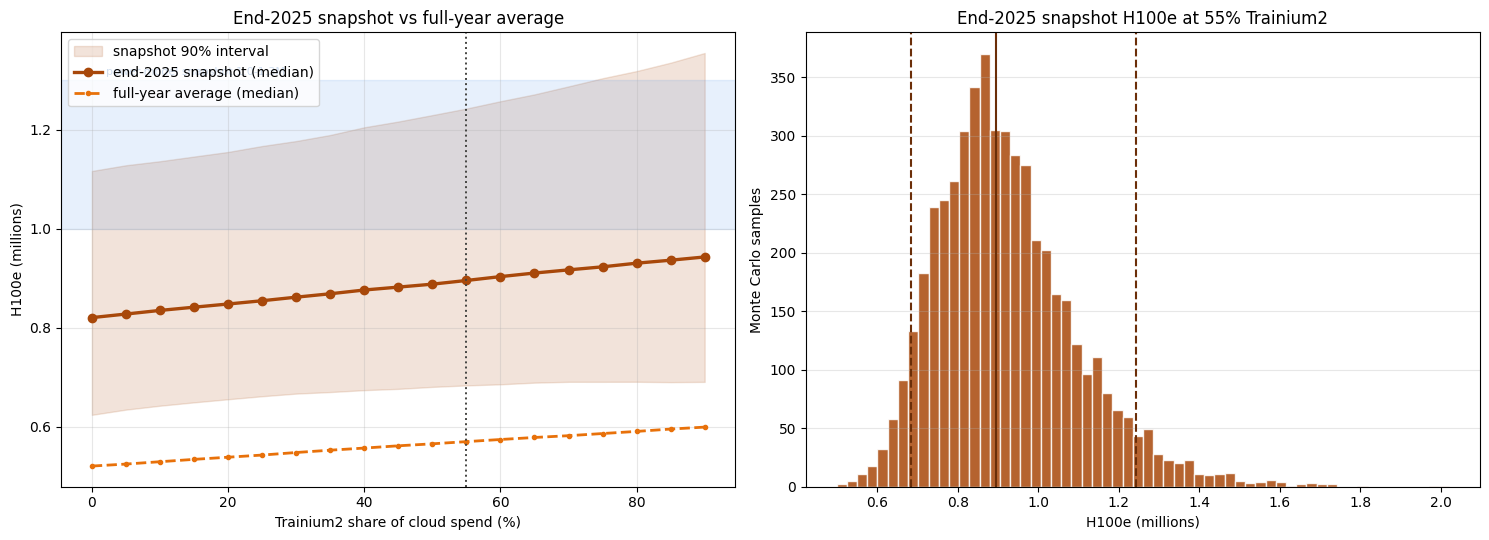

In [15]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: average vs end-2025 snapshot across the Trainium share sweep.
avg_med = np.array([np.median(sweep[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_med = np.array([np.median(sweep_end[s]['total_h100e']) for s in sweep_shares]) / 1e6
end_lo = np.array([percentiles(sweep_end[s]['total_h100e'])[0] for s in sweep_shares]) / 1e6
end_hi = np.array([percentiles(sweep_end[s]['total_h100e'])[2] for s in sweep_shares]) / 1e6

ax_curve.fill_between(sweep_shares * 100, end_lo, end_hi, color='#a8480a', alpha=0.15,
                      label='snapshot 90% interval')
ax_curve.plot(sweep_shares * 100, end_med, color='#a8480a', lw=2.4, marker='o', label='end-2025 snapshot (median)')
ax_curve.plot(sweep_shares * 100, avg_med, color='#e8710a', lw=2.0, ls='--', marker='.',
              label='full-year average (median)')
# Power-model end-2025 snapshot band, for orientation.
ax_curve.axhspan(1.0, 1.3, color='#1a73e8', alpha=0.10)
ax_curve.text(2, 1.31, 'power-model snapshot 1.0-1.3M', fontsize=8, color='#1a5fb4')
ax_curve.axvline(CENTRAL_TRAINIUM_SHARE * 100, color='#444441', ls=':', lw=1.4)
ax_curve.set_title('End-2025 snapshot vs full-year average', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of cloud spend (%)')
ax_curve.set_ylabel('H100e (millions)')
ax_curve.legend(loc='upper left')
ax_curve.grid(True, alpha=0.3)

# Right: snapshot distribution at the central share.
ax_hist.hist(central_end['total_h100e'] / 1e6, bins=60, color='#a8480a', alpha=0.85, edgecolor='white')
for value, style in zip(percentiles(central_end['total_h100e']), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#6b2e08', ls=style, lw=1.5)
ax_hist.set_title(f'End-2025 snapshot H100e at {CENTRAL_TRAINIUM_SHARE:.0%} Trainium2', fontsize=12)
ax_hist.set_xlabel('H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. End-2024 backcast — moved to its own notebook

The backcast originally developed here as §9 (power-anchored end-2025 fleet ×
spend run-rate ratio × 2024/2025 price ratio → ~250k H100e at end-2024) now
lives in **`anthropic_2024_backcast.py`**, with a plain-language walkthrough,
printed and charted intermediates, the SemiAnalysis quarterly cross-check, and
the factor decomposition. It reuses this notebook's spend anchors and the
section-3 run-rate machinery unchanged.

## 10. Takeaways

- **Two outputs from the same dollars.** The 2025 *full-year average* (≈0.57M
  H100e at 55% Trainium) describes the year as a whole; the *end-2025 snapshot*
  (≈0.9M) describes the fleet at year-end, after the spend ramp. The snapshot is
  the right number to set beside the power model's year-end figure.
- **The snapshot closes much of the gap to the power model.** Scaling the average
  up by the ~1.6× year-end run-rate lands it near the bottom of the power model's
  ~1.0–1.3M snapshot band — the two methods are roughly consistent once put on the
  same (year-end) footing.
- **The Trainium markup is the hidden swing factor.** Because Trainium is priced
  off Amazon's \$0.66 cost, whether Anthropic pays near cost or a full cloud margin
  changes how much compute each Trainium dollar buys — amplified by a bigger
  Trainium share.
- **Growth adds two distinct uncertainties** on top of spend and prices: the
  2024→2025 *average* growth (from the two totals), and the *shape* of growth
  within the year. The shape is the bigger unknown for the snapshot — two annual
  totals don't say whether spend ramped early or late, and that alone swings the
  year-end run-rate by a wide margin.
- **The end-2024 backcast now lives in `anthropic_2024_backcast`.** Sliding the
  power-anchored end-2025 fleet down the spend curve puts end-2024 at ~250k
  H100e (90% CI ~125k–430k); see that notebook for the plain-language
  walkthrough, the SemiAnalysis cross-checks, and the factor decomposition.
- This stays a rough alternate. The cleanest ways to tighten it are a better
  Trainium markup estimate, a firmer Trainium-share figure (via the chip-count
  cross-check), and a within-year (e.g. quarterly) spend figure to pin the growth
  shape instead of perturbing it.